In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import numpy.linalg as lin
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import Normalize
import cartopy.crs as ccrs
from matplotlib.colors import BoundaryNorm
from matplotlib.lines import Line2D

In [2]:
plt.rcParams["font.family"] = "Arial"

In [3]:
def calcrx1d(pamt,bincrates):
    p=1-(1/365.25)
    sc=np.cumsum(pamt)/np.sum(pamt)
    rx1day = np.interp(p, sc, bincrates)
    return rx1day

In [4]:
def calcbo(LRdist,HRdist,bincrates):
    scH=np.cumsum(HRdist)/np.sum(HRdist)
    scL=np.cumsum(LRdist)/np.sum(LRdist)
    rH = np.interp(0.5, scH, bincrates)
    rL = np.interp(0.5, scL, bincrates)
    bo = 100*((rH-rL)/rL)
    # centroids for further calculation
    lnrh2 = np.interp(.5, scH, np.log(bincrates))
    lnrh1 = np.interp(.5, scL, np.log(bincrates))
    db=(bincrates[2]-bincrates[1])/bincrates[1]  
    # calculate dp/dln(r)
    nb=len(LRdist);
    dpdlnrc= np.concatenate((np.array([0]),LRdist[2:nb]-LRdist[0:(nb-2)],np.array([0])))/(2*db) # centered difference (2nd order accurate; now used near endpoints)
    prm2=LRdist[:(nb-4)]
    prm1=LRdist[1:(nb-3)]
    prp1=LRdist[3:(nb-1)]
    prp2=LRdist[4:]
    dpdlnr= np.concatenate((np.array([0]),np.array([0]),8*(prp1-prm1)-(prp2-prm2),np.array([0]),np.array([0])))/(12*db) # 4th order accurate 
    dpdlnr[1]=dpdlnrc[1] # fill in with second order accurate near endpoints
    dpdlnr[nb-2]=dpdlnrc[nb-2] 
    dpamt=HRdist-LRdist

    xp = np.log(bincrates[1:]) - lnrh1
    b = lnrh2 - lnrh1
    pamtbo = np.zeros(LRdist.shape)
    pamtbo[1:] = np.interp(xp - b, xp, LRdist[1:])
    #pamtbo[1:]=-(bo/100)*dpdlnr[1:]+LRdist[1:]
    err=100*np.nansum(np.abs(pamtbo[2:]-HRdist[2:]))/np.nansum(np.abs(dpamt[2:]))
    return (bo, pamtbo, err)

# Figure-2: Plotting the rainfall distributions and rx1day values

In [12]:
# AMS standard figure widths in inches
ams_sizes = {
    "one_column": 3.2,
    "two_thirds": 4.5,
    "two_columns": 5.5,
    "more_than_two_columns": 6.5,
}

# Common aspect ratio: width : height = 4:3 → height = width * 0.75
# You can change this based on the visual needs of your plot
aspect_ratio = 0.4


width = ams_sizes["two_columns"]
height = width * aspect_ratio
low_res = 25 #100 ## spatial resolution of low res dataset in kilometers
data1= xr.open_dataset('./../data/raindist_data_10_'+str(low_res)+'km.nc') ## Reading in data. Current structure is that the high resolution distribution is available in both input files.
bincrates=data1.precipitation_bin[1:].values ## rain rate bins
## Plotting begins here
res=[10,25,100,200,500,1000]
colrs=['#081d58','#253494','#225ea8','#1d91c0','#41b6c4','#7fcdbb']
n=0
count=0

otn=np.linspace(1,9,9)
xtickrates=np.append(0,otn*.1)
xtickrates=np.append(xtickrates,otn)
xtickrates=np.append(xtickrates,otn*10)
xtickrates=np.append(xtickrates,otn*100)
xticks=np.interp(xtickrates,bincrates,range(0,len(bincrates))); #% bin numbers associated with nice number rain rate
xticks,indices=np.unique(xticks,return_index=True)
xtickrates=xtickrates[indices]
### Bin width - needed to normalize the rain amount distribution
db=(bincrates[2]-bincrates[1])/bincrates[1];
### Now we plot
plt.figure(figsize=(width,height), constrained_layout=True)
plt.clf()

ax=plt.subplot(121)
rx=[]
for i in range(0,len(res)):
    
    if i==0:
        data1= xr.open_dataset('./../data/raindist_data_'+str(res[i])+'_25km.nc')## Reading in data. Current structure is that the high resolution distribution is available in both input files.
        pamt = data1.pamtH[1:].values ## rain amount of HR dataset
        rx1d=calcrx1d(pamt,bincrates)
        rx.append(rx1d)
    else:
        data1= xr.open_dataset('./../data/raindist_data_10_'+str(res[i])+'km.nc')
        pamt= data1.pamtL[1:].values ## rain amount of LR dataset
        rx1d=calcrx1d(pamt,bincrates)
        rx.append(rx1d)
    plt.plot(range(0,len(pamt)),pamt/db, color=colrs[i], label=str(res[i]/100)+'º',linewidth=1.5)
    plt.xlim((4,130))
    plt.ylim((0,1.3))
    legend_properties = {'weight':'bold','size':9}
    plt.legend(prop=legend_properties)

    ### Annotate with the dry day frequency
    ymin, ymax = ax.get_ylim()
    t1=plt.text(115,ymax*0.90, 'a)',fontsize=12)
    #t2=plt.text(4,ymax*0.90, "{:.1f}".format(dryH)+'%',color='m')
    plt.setp(t1,va='top',ha='left')
    #plt.setp(t2,va='top',ha='left')
    plt.setp(ax,xticks=xticks,xticklabels=['0.1','','','','','','','','','1','','','','','','','','','10','','','','','','','','','100','','','','','','','','','1000'])
    plt.xlabel('Rain rate (mm/d)',fontsize=12,fontweight="bold")
    plt.ylabel('Rain amount (mm/d)',fontsize=12,fontweight="bold")
    plt.xticks(fontsize=10,fontweight="bold")
    plt.yticks(fontsize=10,fontweight="bold")
    for axis in ['top','bottom','left','right']:
        ax.spines[axis].set_linewidth(1.5)
    count+=1
ax2=plt.subplot(122)
rd=pd.DataFrame(rx)
x=['0.1º','0.25º','1º','2º','5º','10º']
plt.bar(x[::-1],rx[::-1],color=colrs[::-1],edgecolor='black', linewidth=2)
plt.xlabel('Spatial Resolution',fontsize=12,fontweight="bold")    
plt.ylabel('RX1day (mm/d)',fontsize=12,fontweight="bold")
plt.xticks(fontsize=10,fontweight="bold")
plt.yticks(fontsize=10,fontweight="bold")
ymin, ymax = ax2.get_ylim()
t2=plt.text(0,ymax*0.90, 'b)',fontsize=12,fontweight='bold')
plt.setp(t2,va='top',ha='right')
for axis in ['top','bottom','left','right']:
    ax2.spines[axis].set_linewidth(1.5)

filename='./../figs/fig2_rain_amount.pdf'
plt.savefig(filename, format="pdf", bbox_inches="tight",dpi=300)
plt.close()

# Figure-3: Joint rain amount distributions distributions

In [15]:
otn=np.linspace(1,9,9)
xtickrates=np.append(0,otn*.1)
xtickrates=np.append(xtickrates,otn)
xtickrates=np.append(xtickrates,otn*10)
xtickrates=np.append(xtickrates,otn*100)
xticks=np.interp(xtickrates,bincrates,range(0,len(bincrates))); #% bin numbers associated with nice number rain rate
xticks,indices=np.unique(xticks,return_index=True)
xtickrates=xtickrates[indices]
### Bin width - needed to normalize the rain amount distribution
db=(bincrates[2]-bincrates[1])/bincrates[1];

ams_sizes = {
    "one_column": 3.2,
    "two_thirds": 4.5,
    "two_columns": 5.5,
    "more_than_two_columns": 6.5,
}

# Common aspect ratio: width : height = 4:3 → height = width * 0.75
# You can change this based on the visual needs of your plot
aspect_ratio = 1


width = 11#ams_sizes["more_than_two_columns"]
height = width * aspect_ratio
res = [1000, 500, 200, 100, 25, 10]  # in km; equivalent to 10º, 5º, ..., 0.1º
plabel=['a)','b)','c)','d)','e)','f)','g)','h)','i)','j)','k)','l)','m)','n)','o)']
n=1
lr=0
pl=0
nrows=len(res)
fig = plt.figure(figsize=(width, height))
for i in range(0,len(res)):
    lr+=1
    for ii in range(0,len(res)):

        if res[ii]==res[::-1][i]:
            break

        data3= xr.open_dataset('./../data/rainjointdist_data_'+str(res[::-1][i])+'_'+str(res[ii])+'km.nc')
        jdL=data3.jdL
        jdH=data3.jdH
        jdF=data3.jdF
        

        ax = fig.add_subplot(nrows, nrows, i * nrows + ii + 1)
        plt.subplots_adjust(wspace=0.18, hspace=0.18, bottom=0.1, right=0.95, top=0.95)
        levels=np.arange(0.0001,0.001,0.0002)
        cs1=ax.contour(np.arange(0,len(jdH.HR_bin[1:])),np.arange(0,len(jdH.LR_bin[1:])),jdH[1:,1:],linewidths=1.5,colors='#081d58',levels=levels)
        cs2=ax.contour(np.arange(0,len(jdL.HR_bin[1:])),np.arange(0,len(jdL.LR_bin[1:])),jdL[1:,1:],linewidths=1.5,colors='#1d91c0',levels=levels,alpha=0.8)
        plt.xlim((4,130))
        #plt.clabel(cs1, inline=1, fontsize=20)
        #plt.clabel(cs2, inline=1, fontsize=20)

        ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
        ax.tick_params(labelleft=False, left=False)
        lims = [
            np.min([ax.get_xlim(), ax.get_ylim()]),  # min of both axes
            np.max([ax.get_xlim(), ax.get_ylim()]),  # max of both axes
        ]
        
        # now plot both limits against eachother
        ax.plot(lims, lims, 'k-', alpha=0.5)
        ax.set_aspect('equal')
        ax.set_xlim(lims)
        ax.set_ylim(lims)
        for axis in ['top','bottom','left','right']:
            ax.spines[axis].set_linewidth(1.5)
        ymin, ymax = ax.get_ylim()
        t1=plt.text(30,ymax*0.98, 'HR: '+str(res[::-1][i]/100)+'º',fontsize=12,fontweight="bold",color='#081d58')
        t2=plt.text(30,ymax*0.85, 'LR: '+str(res[ii]/100)+'º',fontsize=12,fontweight="bold",color='#1d91c0')
        t3=plt.text(5,ymax*0.95, plabel[pl],fontsize=12,fontweight="bold")
        plt.setp(t1,va='top',ha='left')
        plt.setp(t2,va='top',ha='left')
        plt.setp(t3,va='top',ha='left')
        if n in [1,2,3,4]:
            ax.xaxis.set_label_position("top")
            ax.tick_params(axis='x', which='both', bottom=False, top=True, labeltop=True)
            ax.set_xlabel('HR rain rate',fontsize=12,fontweight="bold")
            plt.setp(ax,xticks=xticks,xticklabels=['0.1','','','','','','','','','1','','','','','','','','','10','','','','','','','','','100','','','','','','','','','1000'])
            plt.xticks(fontsize=10,fontweight="bold")
        if n==5:
            ax.set_xlim((0,130))
            ax.tick_params(axis='x', which='both', bottom=True, top=True, labelbottom=True, labeltop=True)
            ax.set_xlabel('HR rain rate',fontsize=12,fontweight="bold")
            ax.set_xticks(xticks)
            ax.set_xticklabels(['0.1','','','','','','','','','1','','','','','','','','','10','','','','','','','','','100','','','','','','','','','1000'],fontsize=10,fontweight="bold")
            plt.xticks(fontsize=10,fontweight="bold")
            # Top x-axis label
            ax_top = ax.twiny()
            ax_top.set_xlim((0,130))
            ax_top.set_xticks(xticks)  # Optional: no ticks
            ax_top.set_xlabel('HR rain rate', fontsize=12, fontweight='bold')
            ax_top.xaxis.set_label_position('top')
            ax_top.set_xticklabels(['0.1','','','','','','','','','1','','','','','','','','','10','','','','','','','','','100','','','','','','','','','1000'],fontsize=10,fontweight="bold")
            ax_top.xaxis.set_label_position("top")
            ax_top.tick_params(top=True, labeltop=True)
        if n in [1,6,10,13,15]:
            ax.tick_params(labelleft=True, left=True)
            ax.set_yticks(xticks)
            ax.set_yticklabels(['0.1','','','','','','','','','1','','','','','','','','','10','','','','','','','','','100','','','','','','','','','1000'],fontsize=10,fontweight="bold")
            plt.ylabel('LR rain rate',fontsize=12,fontweight="bold")
        if n in [5,9,12,14]:
            #t5=plt.text(180,ymax*0.8, 'HR: '+str(res[::-1][i]/100)+'º', rotation=270,fontsize=14,fontweight="bold",color='#081d58')
            #plt.setp(t5,va='top',ha='left')
            plt.xlabel('HR rain rate',fontsize=12,fontweight="bold")
            ax.tick_params(labelleft=True, left=True)
            ax.yaxis.tick_left()
            ax.set_yticks(xticks)
            ax.set_yticklabels(['0.1','','','','','','','','','1','','','','','','','','','10','','','','','','','','','100','','','','','','','','','1000'],fontsize=10,fontweight="bold")
            ax.yaxis.set_label_position("right")
            ax.set_ylabel('LR rain rate',fontsize=12,fontweight="bold")
            
            ax.yaxis.tick_right()
            ax.set_yticks(xticks)
            ax.set_yticklabels(['0.1','','','','','','','','','1','','','','','','','','','10','','','','','','','','','100','','','','','','','','','1000'])
            ax.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=True)
            plt.setp(ax,xticks=xticks,xticklabels=['0.1','','','','','','','','','1','','','','','','','','','10','','','','','','','','','100','','','','','','','','','1000'])
            plt.xticks(fontsize=10,fontweight="bold")
        if n==15:
            plt.xlabel('HR rain rate',fontsize=12,fontweight="bold")
            ax.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=True)
            plt.setp(ax,xticks=xticks,xticklabels=['0.1','','','','','','','','','1','','','','','','','','','10','','','','','','','','','100','','','','','','','','','1000'])
            plt.xticks(fontsize=10,fontweight="bold")
            ax.tick_params(labelleft=True, left=True)     # Enable left y-axis
            ax.tick_params(labelright=True, right=True)   # Enable right y-axis
            # Create a twin y-axis (right)
            ax_left = ax.twinx()
            ax_left.set_ylabel('LR rain rate', fontsize=12, fontweight='bold')
            ax_left.set_yticks(xticks)
            ax_left.set_yticklabels(['0.1','','','','','','','','','1','','','','','','','','','10','','','','','','','','','100','','','','','','','','','1000'],fontsize=10,fontweight="bold")
            ax_left.yaxis.set_label_position("right")
            ax_left.yaxis.tick_right()
        n+=1
        pl=pl+1
         
# Create a full-figure invisible Axes for annotation
fig_ax = fig.add_axes([0, 0, 1, 1], zorder=-1)
fig_ax.axis('off')  # Hide everything

# Add an arrow across the figure
fig_ax.annotate(
    '',  # no text
    xy=(0.85, 0.2),  # arrowhead location in figure coords
    xytext=(0.15, 0.2),  # tail location
    xycoords='figure fraction',
    textcoords='figure fraction',
    arrowprops=dict(arrowstyle="->", linewidth=3, color='#1d91c0')
)
# Text just above the arrow (you can move it below by reducing 0.12 to 0.08)
fig.text(0.5, 0.2, 'Finer Low Resolution (LR)', ha='center', va='bottom',
         fontsize=14, fontweight='bold', color='#1d91c0')


# Vertical arrow (right side of figure)
fig_ax = fig.add_axes([0, 0, 1, 1], zorder=-1)
fig_ax.axis('off')  # Hide everything
fig_ax.annotate(
    '', 
    xy=(0.9, 0.9),       # arrowhead at top
    xytext=(0.9, 0.3),   # tail at bottom
    xycoords='figure fraction',
    textcoords='figure fraction',
    arrowprops=dict(arrowstyle='->', linewidth=3,color='#081d58'),
)

# Label just to the left of the arrow
fig.text(0.88, 0.6, 'Finer Higher Resolution (HR)', rotation=90,
         va='center', ha='right', fontsize=14, fontweight='bold',color='#081d58')

filename='./../figs/fig3_joint_dist.pdf'
plt.savefig(filename, format="pdf", bbox_inches="tight",dpi=300)
plt.close()
            

# Figure-4: Rain amount differences and shift values

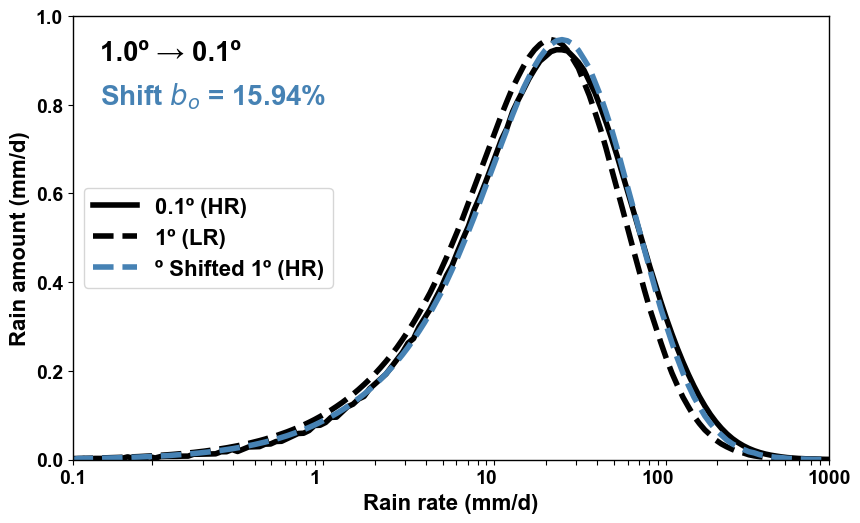

In [16]:
## Calculating bo
otn=np.linspace(1,9,9)
xtickrates=np.append(0,otn*.1)
xtickrates=np.append(xtickrates,otn)
xtickrates=np.append(xtickrates,otn*10)
xtickrates=np.append(xtickrates,otn*100)
xticks=np.interp(xtickrates,bincrates,range(0,len(bincrates))); #% bin numbers associated with nice number rain rate
xticks,indices=np.unique(xticks,return_index=True)
xtickrates=xtickrates[indices]
### Bin width - needed to normalize the rain amount distribution
db=(bincrates[2]-bincrates[1])/bincrates[1];

ams_sizes = {
    "one_column": 3.2,
    "two_thirds": 4.5,
    "two_columns": 5.5,
    "more_than_two_columns": 6.5,
}

# Common aspect ratio: width : height = 4:3 → height = width * 0.75
# You can change this based on the visual needs of your plot
aspect_ratio = 0.6


width = 20#ams_sizes["two_columns"]
height = width * aspect_ratio
res = [100, 10]  # in km; equivalent to 10º, 5º, ..., 0.1º
plabel=['a)','b)','c)','d)','e)','f)','g)','h)','i)','j)','k)','l)','m)','n)','o)']
n=1
lr=0
pl=0
nrows=len(res)
fig = plt.figure(figsize=(width, height))
for i in range(0,len(res)):
    lr+=1
    for ii in range(0,len(res)):

        if res[ii]==res[::-1][i]:
            break

        data1= xr.open_dataset('./../data/raindist_data_'+str(res[::-1][i])+'_'+str(res[ii])+'km.nc')
        pamtH = data1.pamtH[1:].values
        pamtL = data1.pamtL[1:].values
        bincrates=data1.precipitation_bin[1:].values ## rain rate bins
        db=(bincrates[2]-bincrates[1])/bincrates[1];
        modes =calcbo(pamtL,pamtH,bincrates)
        pamtshift = modes[1]
        err=modes[2]

        Po1=(pamtshift)-pamtL ## Difference in rain amount at 0.1º and shifted 1º 
        Po=((pamtH)-(pamtL))

        ### Plotting the difference between HR and LR' combined plot

        ax = fig.add_subplot(nrows, nrows, i * nrows + ii + 1)
        plt.subplots_adjust(wspace=0.3, hspace=0.3, bottom=0.1, top=0.95, right=0.95, left=0.08)

        lwidth=4

        plt.plot(range(0,len(Po)),pamtH/db,color='black',linewidth=lwidth,label='0.1º (HR)')
        plt.plot(range(0,len(Po)),pamtL/db,color='black',linewidth=lwidth,linestyle='--',label='1º (LR)')
        plt.plot(range(0,len(Po1)),pamtshift/db,color='steelblue',linewidth=lwidth,linestyle='--',label='º Shifted 1º (HR)')
        
        plt.xlim((4,130))
        plt.ylim((0,1))
        #axs[count].text(1,-0.5, "{:.2f}".format(err0)+'%',color='black')
        ymin, ymax = ax.get_ylim()
        plt.text(5,ymax*0.9, str(res[ii]/100)+'º → '+str(res[::-1][i]/100)+'º',fontsize=20,fontweight="bold")
        plt.text(5,ymax*0.8, 'Shift $b_o$ = 15.94%',fontsize=20,fontweight="bold",color='steelblue')
        #plt.text(120,ymax*0.85,str(round(errs,2))+'%',color='steelblue',fontsize=30,fontweight="bold")
        #plt.text(115,ymax*0.70,str(round(errn,2))+'%',color='orange',fontsize=30,fontweight="bold")
        #plt.text(120,ymax*0.55,str(round(err,2))+'%',color='deeppink',fontsize=30,fontweight="bold")
        plt.setp(ax,xticks=xticks,xticklabels=['0.1','','','','','','','','','1','','','','','','','','','10','','','','','','','','','100','','','','','','','','','1000'])
        plt.xticks(fontsize=14,weight='bold')
        plt.yticks(fontsize=14,weight='bold')
        plt.ylabel('Rain amount (mm/d)',fontsize=16,weight='bold')
        plt.xlabel('Rain rate (mm/d)',fontsize=16,weight='bold')
        plt.legend(fontsize=30,prop={'size': 16,'weight': 'bold'})
        for spine in ax.spines.values():
            spine.set_linewidth(1)

            
        n+=1
        pl=pl+1
        if res[ii]==res[-1]:
            n=n+(i+1)

filename='/Users/akshayrajeev/Stuff/Projects/IMERG_trends/fig_shiftdist.pdf'
#plt.savefig(filename, format="pdf", bbox_inches="tight",dpi=300)
#plt.close()

In [18]:
## Calculating bo
otn=np.linspace(1,9,9)
xtickrates=np.append(0,otn*.1)
xtickrates=np.append(xtickrates,otn)
xtickrates=np.append(xtickrates,otn*10)
xtickrates=np.append(xtickrates,otn*100)
xticks=np.interp(xtickrates,bincrates,range(0,len(bincrates))); #% bin numbers associated with nice number rain rate
xticks,indices=np.unique(xticks,return_index=True)
xtickrates=xtickrates[indices]
### Bin width - needed to normalize the rain amount distribution
db=(bincrates[2]-bincrates[1])/bincrates[1];

ams_sizes = {
    "one_column": 3.2,
    "two_thirds": 4.5,
    "two_columns": 5.5,
    "more_than_two_columns": 6.5,
}

# Common aspect ratio: width : height = 4:3 → height = width * 0.75
# You can change this based on the visual needs of your plot
aspect_ratio = 0.6


width = 12#ams_sizes["two_columns"]
height = width * aspect_ratio
res = [500, 200, 100, 25, 10]  # in km; equivalent to 10º, 5º, ..., 0.1º
plabel=['a)','b)','c)','d)','e)','f)','g)','h)','i)','j)','k)','l)','m)','n)','o)']
n=1
lr=0
pl=0
nrows=len(res)
fig = plt.figure(figsize=(width, height))
for i in range(0,len(res)):
    lr+=1
    for ii in range(0,len(res)):

        if res[ii]==res[::-1][i]:
            break

        data1= xr.open_dataset('./../data/raindist_data_'+str(res[::-1][i])+'_'+str(res[ii])+'km.nc')
        pamtH = data1.pamtH[1:].values
        pamtL = data1.pamtL[1:].values
        bincrates=data1.precipitation_bin[1:].values ## rain rate bins
        db=(bincrates[2]-bincrates[1])/bincrates[1];
        modes =calcbo(pamtL,pamtH,bincrates)
        pamtshift = modes[1]
        err=modes[2]

        Po1=(pamtshift)-pamtL ## Difference in rain amount at 0.1º and shifted 1º 
        Po=((pamtH)-(pamtL))

        ### Plotting the difference between HR and LR' combined plot

        ax = fig.add_subplot(nrows, nrows, i * nrows + ii + 1)
        plt.subplots_adjust(wspace=0.3, hspace=0.3, bottom=0.1, top=0.95, right=0.95, left=0.08)

        lwidth=2

        plt.axhline(y = 0, color = 'gray')
        plt.plot(range(0,len(Po)),Po/db,color='black',linewidth=1,label=str(res[ii]/100)+'º-'+str(res[::-1][i]/100)+'º Difference')
        plt.plot(range(0,len(Po1)),Po1/db,color='steelblue',linewidth=lwidth,label=str(res[ii]/100)+'º-'+str(res[::-1][i]/100)+'º Shift')
        
        plt.xlim((4,130))

        #axs[count].text(1,-0.5, "{:.2f}".format(err0)+'%',color='black')
        ymin, ymax = ax.get_ylim()
        plt.text(5,ymax*0.72, plabel[pl]+' '+str(res[ii]/100)+'º → '+str(res[::-1][i]/100)+'º',fontsize=12,fontweight="bold")
        plt.text(5,ymax*0.35,'Error ('+str(round(err,2))+'%)',color='grey',fontsize=12,fontweight="bold")
        #plt.text(120,ymax*0.85,str(round(errs,2))+'%',color='steelblue',fontsize=30,fontweight="bold")
        #plt.text(115,ymax*0.70,str(round(errn,2))+'%',color='orange',fontsize=30,fontweight="bold")
        #plt.text(120,ymax*0.55,str(round(err,2))+'%',color='deeppink',fontsize=30,fontweight="bold")
        plt.setp(ax,xticks=xticks,xticklabels=['0.1','','','','','','','','','1','','','','','','','','','10','','','','','','','','','100','','','','','','','','','1000'])
        plt.xticks(fontsize=10,weight='bold')
        plt.yticks(fontsize=10,weight='bold')
        #plt.legend(fontsize=30,prop={'size': 30,'weight': 'bold'})
        for spine in ax.spines.values():
            spine.set_linewidth(1)
        if n in [1,2,3,4]:
            t4=plt.text(40,ymax*1.4, 'LR: '+str(res[ii]/100)+'º',fontsize=14,fontweight="bold",color='#1d91c0')
            plt.setp(t4,va='top',ha='left')
        if n in [1,5,8,10]:
            
            plt.ylabel('$\mathbf{\mathit{\Delta}}$P (mm/d)',fontsize=12,weight='bold')
            
        if n in [4,7,9,10]:
            t5=plt.text(145,ymax*0.8, 'HR: '+str(res[::-1][i]/100)+'º', rotation=270,fontsize=14,fontweight="bold",color='#081d58')
            plt.setp(t5,va='top',ha='left')
            plt.xlabel('Rain rate (mm/d)',fontsize=12,weight='bold')
        n+=1
        pl=pl+1
        if res[ii]==res[-1]:
            n=n+(i+1)

res=[ 1000, 500, 200, 100, 25, 10]
shift_matrix = np.full((len(res), len(res)), np.nan)
for i in range(0,len(res)):
    for ii in range(0,len(res)):
        if res[ii]==res[::-1][i]:
            break
        data1= xr.open_dataset('./../data/raindist_data_'+str(res[::-1][i])+'_'+str(res[ii])+'km.nc')
        pamtH = data1.pamtH[1:].values
        pamtL = data1.pamtL[1:].values
        bincrates=data1.precipitation_bin[1:].values ## rain rate bins
        db=(bincrates[2]-bincrates[1])/bincrates[1];
        modes = calcbo(pamtL,pamtH,bincrates)
        shift_matrix[ii, i] = modes[0].item()
#modified_matrix = shift_matrix[:, 1:]  # drop first column for x-axis
        
# Add a new axes at bottom left (custom position)
# [left, bottom, width, height] in fraction of figure dimensions (0 to 1)
ax2 = fig.add_axes([0.5, 0.15, 0.4, 0.4])  # adjust values to fit your layout

sns.heatmap(
    shift_matrix.T,
    xticklabels=['10º','5º','2º','1º','0.25º',''],
    yticklabels=['0.1º','0.25º','1º','2º','5º',''],  # reverse y-axis to match top-left origin
    cmap='Blues',
    annot=True, fmt=".2f",
    annot_kws={"fontsize": 11, "fontweight": "bold"},
    cbar_kws={
        "label": "Shift (%)",
        "orientation": "horizontal",
        "pad": -0.1,
        "shrink": 0.5
    },
    vmin=0, vmax=150,
    square=True
)
# Modify colorbar appearance
cbar = ax2.collections[0].colorbar
cbar.ax.tick_params(labelsize=10)
cbar.set_label("Shift $b_o$ (%)", fontsize=12, fontweight='bold')

# Manually shift the colorbar to the right
pos = cbar.ax.get_position()
cbar.ax.set_position([pos.x0 - 0.01, pos.y0, pos.width, pos.height])  # shift x0 right by 0.05
cbar.ax.tick_params(labelsize=10)  # font size
for label in cbar.ax.get_xticklabels():  # for horizontal
    label.set_fontweight('bold')

# 2. Set bold colorbar border (outline)
for spine in cbar.ax.spines.values():
    spine.set_linewidth(1)
    spine.set_edgecolor('black')

# Enable top x-axis and left y-axis ticks
ax2.xaxis.tick_top()
ax2.yaxis.tick_left()

# Ensure tick labels are shown
ax2.tick_params(
    top=True, labeltop=True,
    left=True, labelleft=True,
    bottom=False, labelbottom=False,
    right=False, labelright=False,
    length=0  # Hides the tick lines
)

# Set bold and fontsize for tick labels
plt.setp(ax2.get_xticklabels(), fontsize=11, fontweight='bold')
plt.setp(ax2.get_yticklabels(), fontsize=11, rotation=0,fontweight='bold')
ax2.set_xlabel('Low Resolution (LR)', fontsize=12, fontweight='bold', labelpad=10)
ax2.xaxis.set_label_position('top')
ax2.set_ylabel('High Resolution (HR)', fontsize=12, fontweight='bold', labelpad=10)
#ax2.yaxis.set_label_position('right')
plt.ylabel('High Resolution (HR)', fontsize=12, fontweight='bold')
#plt.setp(ax2.get_xticklabels(), fontsize=10, fontweight='bold')
#plt.setp(ax2.get_yticklabels(), rotation=360, fontsize=10, fontweight='bold')
filename='./../figs/fig5_rain_diff.pdf'
plt.savefig(filename, format="pdf", bbox_inches="tight",dpi=300)
plt.close()

<>:84: SyntaxWarning: invalid escape sequence '\m'
<>:84: SyntaxWarning: invalid escape sequence '\m'
/var/folders/0y/zzjz_w1n0pscwp0y_p3q04jr0000gn/T/ipykernel_2540/1241387458.py:84: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel('$\mathbf{\mathit{\Delta}}$P (mm/d)',fontsize=12,weight='bold')


# Figure-6: Spatial variability of shift, narrowing and their errors

In [22]:
%timeit
sdata=xr.open_dataset('./../data/bo_10_100km_10v.nc')
zdata=xr.open_dataset('./../data/bo_zonal_10_100km.nc')
sh_trop=zdata['shift'].sel(lat=slice(-60,60));sh_N=zdata['shift'].sel(lat=slice(60,90));sh_S=zdata['shift'].sel(lat=slice(-90,-60))
er_trop=zdata['error'].sel(lat=slice(-60,60));er_N=zdata['error'].sel(lat=slice(60,90));er_S=zdata['error'].sel(lat=slice(-90,-60))
ams_sizes = {
    "one_column": 3.2,
    "two_thirds": 4.5,
    "two_columns": 5.5,
    "more_than_two_columns": 6.5,
}

# Common aspect ratio: width : height = 4:3 → height = width * 0.75
# You can change this based on the visual needs of your plot
aspect_ratio = 0.65


width = ams_sizes["more_than_two_columns"]
height = width * aspect_ratio

# Extract lat, lon, and data (ensure it's 2D)
levels=np.arange(-50,60,10)
cmap = plt.get_cmap('RdBu', len(levels)+1)  # Discretize the colormap
norm = BoundaryNorm(boundaries=levels, ncolors=cmap.N, extend='both')

# Plot
fig = plt.figure(figsize=(width, height))
plt.subplots_adjust(wspace=0.4, hspace=0.4, bottom=0.1, right=0.95, top=0.95)

lon, lat = np.meshgrid(sdata['lon'], sdata['lat'])
ax1 = fig.add_subplot(2, 2, 1, projection=ccrs.Robinson())
pcm1 = ax1.pcolormesh(
    lon, lat, sdata['shift'].T,
    transform=ccrs.PlateCarree(),
    cmap=cmap,
    norm=norm,
    shading='auto'
)
pcm1.set_rasterized(True)

ax1.coastlines()
ax1.gridlines()
ymin, ymax = ax1.get_ylim()
xmin, xmax = ax1.get_xlim()
plt.text(0.95*xmin,0.90*ymax,'a)',fontsize=12,fontweight='bold')

cbar = fig.colorbar(pcm1, ax=ax1, orientation='horizontal', label='Shift (%)',fraction=0.07, pad=0.04)
cbar.ax.tick_params(labelsize=12)  # font size of tick labels
for tick_label in cbar.ax.get_xticklabels():  # use get_yticklabels() for vertical bar
    tick_label.set_fontweight('bold')
cbar.set_label("Shift (%)", fontsize=12, fontweight='bold', labelpad=10)

## Zonal shift 
ax2=fig.add_subplot(2,2,2)
ax2.plot(sh_trop,sh_trop['lat'],'dodgerblue',linewidth=1)
ax2.plot(sh_N,sh_N['lat'],'dodgerblue',linewidth=1,alpha=0.5)
ax2.plot(sh_S,sh_S['lat'],'dodgerblue',linewidth=1,alpha=0.5)
ax2.spines[['right', 'top']].set_visible(False)
ax2.spines[['left', 'bottom']].set_linewidth(1.5)
lat_labels= [-90,-60,-30,0,30,60,90]
#ax2.set_yticks(np.sin(np.deg2rad(lat_labels)),lat_labels)
ax2.set_yticks(lat_labels)
ax2.set_xticks([0,10,20,30,40])
ax2.set_xlim([0,40])
ax2.set_ylim([-90,90])
ax2.vlines([10,20,30],ymin = -90, ymax = 90,linestyles='dashed',linewidth=1.5, color='grey')
ax2.set_xlabel('Shift (%)',fontsize=10,fontweight='bold')
ax2.set_ylabel('Latitude',fontsize=10,fontweight='bold')
chartBox = ax2.get_position() 
ax2.set_position([chartBox.x0,  
                  chartBox.y0*1.07, 
                  chartBox.width * 0.3, 
                  chartBox.height*0.75])
ymin, ymax = ax2.get_ylim()
xmin, xmax = ax2.get_xlim()
plt.text(40,0.85*ymax,'b)',fontsize=12,fontweight='bold')


# Spatial distribution of Error
levels=np.arange(0,110,10)
cmap = plt.get_cmap('YlGnBu', len(levels)+1)  # Discretize the colormap
norm = BoundaryNorm(boundaries=levels, ncolors=cmap.N, extend='both')

ax3 = fig.add_subplot(2, 2, 3, projection=ccrs.Robinson())
pcm2 = ax3.pcolormesh(
    lon, lat, sdata['error'].T,
    transform=ccrs.PlateCarree(),
    cmap=cmap,
    norm=norm,
    shading='auto'
)
pcm2.set_rasterized(True)

ax3.coastlines()
ax3.gridlines()
ymin, ymax = ax3.get_ylim()
xmin, xmax = ax3.get_xlim()
plt.text(0.95*xmin,0.90*ymax,'c)',fontsize=12,fontweight='bold')

cbar = fig.colorbar(pcm2, ax=ax3, orientation='horizontal', label='Error (%)',fraction=0.07, pad=0.04,extend='max')
cbar.ax.tick_params(labelsize=12)  # font size of tick labels
for tick_label in cbar.ax.get_xticklabels():  # use get_yticklabels() for vertical bar
    tick_label.set_fontweight('bold')
cbar.set_label("Error (%)", fontsize=12, fontweight='bold', labelpad=10)

# Zonal plot of error
ax4=fig.add_subplot(2,2,4)
ax4.plot(er_trop,er_trop['lat'],'black',linewidth=1)
ax4.plot(er_N,er_N['lat'],'black',linewidth=1,alpha=0.5)
ax4.plot(er_S,er_S['lat'],'black',linewidth=1,alpha=0.5)
ax4.spines[['right', 'top']].set_visible(False)
ax4.spines[['left', 'bottom']].set_linewidth(1.5)
lat_labels= [-90,-60,-30,0,30,60,90]
#ax2.set_yticks(np.sin(np.deg2rad(lat_labels)),lat_labels)
ax4.set_yticks(lat_labels)
ax4.set_xticks([0,25,50,75,100])
ax4.set_xlim([0,100])
ax4.set_ylim([-90,90])
ax4.vlines([25,50,75],ymin = -90, ymax = 90,linestyles='dashed',linewidth=1.5, color='grey')
ax4.set_xlabel('Error (%)',fontsize=10,fontweight='bold')
ax4.set_ylabel('Latitude',fontsize=10,fontweight='bold')
chartBox = ax4.get_position() 
ax4.set_position([chartBox.x0,  
                  chartBox.y0*1.5, 
                  chartBox.width * 0.35, 
                  chartBox.height*0.72])
ymin, ymax = ax4.get_ylim()
xmin, xmax = ax4.get_xlim()
plt.text(100,0.85*ymax,'d)',fontsize=12,fontweight='bold')

filename='./../figs/fig6_spatial.pdf'
plt.savefig(filename, format="pdf", bbox_inches="tight")
plt.close()

# Table-1: Extreme rainfall

In [24]:
## Calculation of shift and narrowing modes
res=[10,25,100,200,500,1000]
n=0
hres=[];lres=[]
rx1=[];rx1m=[];rx1o=[]
difm=[];difo=[]
for i in range(0,len(res)):
    n=n+1
    for ii in range(n,len(res)):
        data1= xr.open_dataset('./../data/raindist_data_'+str(res[i])+'_'+str(res[ii])+'km.nc')## Reading in data. Current structure is that the high resolution distribution is available in both input files.
        pamtH = data1.pamtH[1:].values ## rain amount of HR dataset
        pamtL= data1.pamtL[1:].values ## rain amount of LR dataset
        ppdfH= data1.ppdfH[1:].values ## rain frequency of HR dataset
        ppdfL=data1.ppdfL[1:].values ## rain frequency of LR dataset
        bincrates=data1.precipitation_bin[1:].values ## rain rate bins
        omodes=calcbo(pamtL,pamtH,bincrates)
        pamtbo=omodes[1]
        rx1day=calcrx1d(pamtH,bincrates)
        rx1day_o=calcrx1d(pamtbo,bincrates)
        diffo=100*(rx1day-rx1day_o)/rx1day_o
        rx1.append(rx1day)
        rx1o.append(rx1day_o)
        difo.append(diffo)
        hres.append(res[i])
        lres.append(res[ii])
df2=pd.DataFrame({'HR' : hres,'LR' : lres,'rx1day' : np.round(rx1,2),'Reproduced rx1day':np.round(rx1o,2),'Percentage Difference':np.round(difo,2)})

In [25]:
df2

,HR,LR,rx1day,Reproduced rx1day,Percentage Difference
0,10,25,298.95,291.96,2.39
1,10,100,298.95,266.67,12.10
2,10,200,298.95,232.83,28.40
3,10,500,298.95,165.26,80.90
4,10,1000,298.95,119.18,150.83
5,25,100,281.61,258.76,8.83
6,25,200,281.61,225.15,25.08
7,25,500,281.61,159.55,76.50
8,25,1000,281.61,115.46,143.89
9,100,200,229.81,200.69,14.51


# Table-2: Shift modes in observations

In [26]:
## Calculation of shift mode
res = [100, 200, 500, 1000]
datasets = ['IMERG','GPCP', 'CMORPH_v1.0_CRT', 'GIRAFE', 'PERSIANN_v1_r1']
dataset_names = {
    'IMERG': 'IMERG',
    'GPCP': 'GPCP',
    'CMORPH_v1.0_CRT': 'CMORPH',
    'GIRAFE': 'GIRAFE',
    'PERSIANN_v1_r1': 'PERSIANN'
}

# Prepare results
records = []

# Loop over resolution pairs
for i in range(len(res)):
    for ii in range(i + 1, len(res)):
        hr = res[i]
        lr = res[ii]
        row = {'HR': f'{hr//100}º', 'LR': f'{lr//100}º'}
        for dd in datasets:
            file_path = './../data/frogs/raindist_'+dd+'_'+str(hr)+'_'+str(lr)+'km.nc'

            data1 = xr.open_dataset(file_path)
            pamtH = data1.pamtH[1:].values
            pamtL = data1.pamtL[1:].values
            ppdfH = data1.ppdfH[1:].values
            ppdfL = data1.ppdfL[1:].values
            bincrates = data1.precipitation_bin[1:].values

            # Calculate shift
            modes = calcbo(pamtL, pamtH, bincrates)
            #modes = calcbo(pamtL, pamtH, bincrates)
            row[dataset_names[dd]] = np.round(modes[0], 2)

        records.append(row)

# Create final DataFrame
df_summary = pd.DataFrame(records)

In [27]:
df_summary ## shift values

,HR,LR,IMERG,GPCP,CMORPH,GIRAFE,PERSIANN
0,1º,2º,13.53,14.90,16.65,12.95,8.30
1,1º,5º,50.86,55.62,63.58,50.89,31.83
2,1º,10º,111.15,120.29,137.98,112.82,71.01
3,2º,5º,32.88,35.44,40.24,33.59,21.73
4,2º,10º,85.98,91.72,104.02,88.42,57.90
5,5º,10º,39.96,41.55,45.48,41.04,29.71
